# SUPERVISED LEARNING - MODEL EVALUATION

## PART 1 – THEORETICAL FOUNDATION

### S1 - What Is Supervised Learning 

Q1 - Supervised Learning khác Unsupervised Learning ở điểm nào? 
- Supervised Learning và Unsupervised Learning khác nhau chủ yếu ở việc dữ liệu có nhãn hay không.
    - Trong Supervised Learning, mô hình được huấn luyện bằng dữ liệu đã có sẵn đáp án đúng (label). Mục tiêu là học mối quan hệ giữa dữ liệu đầu vào và kết quả đầu ra để dự đoán cho dữ liệu mới. Ví dụ: dự đoán giá nhà hoặc phân loại email spam.
    - Ngược lại, Unsupervised Learning sử dụng dữ liệu không có nhãn. Mô hình không biết trước đáp án mà sẽ tự tìm cấu trúc, quy luật hoặc nhóm dữ liệu tương tự nhau. Ví dụ: phân cụm khách hàng hoặc giảm chiều dữ liệu.

- Tóm lại:
    - Supervised Learning: học từ dữ liệu có nhãn để dự đoán kết quả.
    - Unsupervised Learning: học từ dữ liệu không nhãn để khám phá cấu trúc ẩn trong dữ liệu.

Q2 - Cho ví dụ thực tế: 3 bài toán Regression và 3 bài toán Classification.

Regression
- Dự đoán thời gian nằm viện của bệnh nhân.
- Dự đoán huyết áp của bệnh nhân.
- Dự đoán chi phí điều trị.

Classification
- Phân loại bệnh nhân có mắc ung thư hay không.
- Phân loại ảnh X-quang COVID-19 dương tính hay âm tính.
- Phân loại mức độ bệnh: nhẹ, trung bình, nặng.

Q3 - Dữ liệu "labeled" nghĩa là gì? Ai tạo ra label?

Dữ liệu “labeled” là dữ liệu đã được gắn sẵn kết quả đúng (label) cho mỗi mẫu dữ liệu.

Ví dụ:
* Email → “spam” hoặc “không spam”
* Ảnh → “mèo” hoặc “chó”
* Nhà → giá bán thực tế

Label thường được tạo bởi:
* Con người gán nhãn thủ công
* Chuyên gia trong lĩnh vực liên quan
* Hoặc lấy từ dữ liệu/hệ thống đã có sẵn kết quả thực tế.


### S2 – Regression vs Classification

Xác định Regression hay Classification cho mỗi bài toán sau và giải thích 
lý do:
1. Dự đoán số lượt xem của một video YouTube 
2. Phân loại email là spam hay không 
3. Dự đoán điểm thi của sinh viên 
4. Nhận diện cảm xúc trong ảnh (vui/buồn/tức/ngạc nhiên) 
5. Dự báo doanh thu quý tới 

1. **Dự đoán số lượt xem của một video YouTube** → **Regression** : Vì kết quả là một giá trị số liên tục (số lượt xem).

2. **Phân loại email là spam hay không** → **Classification** : Vì kết quả là các nhãn rời rạc: spam hoặc không spam.

3. **Dự đoán điểm thi của sinh viên** → **Regression** : Vì điểm thi là giá trị số liên tục.

4. **Nhận diện cảm xúc trong ảnh (vui/buồn/tức/ngạc nhiên)** → **Classification** : Vì mô hình cần phân loại vào các nhóm cảm xúc khác nhau.

5. **Dự báo doanh thu quý tới** → **Regression** : Vì doanh thu là giá trị số liên tục.


### S3 – The 7-Stage Process

**PROCESS :** Thu thập dữ liệu  →  EDA  →  Tiền xử lý  →  Chia tập  →  Huấn luyện  →  Tinh chỉnh  →  Đánh giá  →  Triển khai

**Q1 -  Why should we split the train/test datasets BEFORE normalizing the data?**

Phải chia train/test trước khi chuẩn hóa dữ liệu để tránh **data leakage**.

Nếu scale toàn bộ dataset trước rồi mới split:

* Thông tin từ test set đã bị “lộ” vào quá trình huấn luyện.
* Model sẽ đánh giá “ảo”, kết quả cao hơn thực tế.

Quy trình:
```python
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
```


**Q2 - What is the difference between a validation-set and a test-set?**

Validation set dùng trong quá trình phát triển mô hình:
- Tune hyperparameter
- Chọn model tốt nhất
- Theo dõi overfitting
- Dùng nhiều lần trong quá trình training

Test set dùng để đánh giá cuối cùng:
- Kiểm tra hiệu năng thực tế của model
- Chỉ nên dùng một lần sau khi hoàn tất training và tunin

**Q3 - What does the problem that cross-validation solves that single-split systems cannot?**

- Single split chỉ đánh giá model trên một lần chia dữ liệu duy nhất → kết quả dễ bị phụ thuộc vào cách chia train/test.
- Cross-validation đánh giá model trên nhiều cách chia khác nhau → kết quả ổn định và đáng tin cậy hơn.

### S4 - Train/Test Split 

## PART 2 - METRICS REVIEWS

### S5 – Metrics for Regression

Q : A house price prediction model has an RMSE of 50 million VND and an R² of 0.85. Is this model good? Explain.

**Mô hình này được xem là khá tốt.**

- RMSE = 50 triệu đồng nghĩa là trung bình dự đoán sai khoảng 50 triệu đồng so với giá thực tế.
    - Sai số này lớn hay nhỏ còn phụ thuộc vào mặt bằng giá nhà.
    - Ví dụ:
        - Nhà giá 5–10 tỷ → sai số 50 triệu là khá thấp.
        - Nhà giá 200 triệu → sai số này rất lớn.

- R² = 0.85 nghĩa là mô hình giải thích được khoảng 85% sự biến thiên của giá nhà.
    - Đây là mức khá cao.
    - Cho thấy model học được mối quan hệ tốt giữa features và giá nhà.

**Kết luận:**
- Với R² = 0.85, mô hình nhìn chung tốt.
- RMSE cần được đánh giá trong bối cảnh giá trị thực tế của dataset.


### S6 - Metrics for Classification

**Credit Card Fraud (1% fraud, 99% normal)**

**1. If the model consistently predicts "normal," what is the Accuracy?**

Nếu model luôn dự đoán “bình thường” thì Accuracy = 99%. Vì:
- 99% giao dịch là bình thường
- Model đoán tất cả là bình thường nên đúng 99%.

**2. Why is Accuracy not appropriate here?**

Accuracy không phù hợp vì dataset bị mất cân bằng (imbalanced dataset).

Dù Accuracy rất cao:
- Model thực tế không phát hiện được bất kỳ giao dịch gian lận nào.
- Giá trị sử dụng gần như bằng 0.

Accuracy che giấu việc:
- False Negative rất nhiều
- Model bỏ sót toàn bộ fraud cases.

**3. Which metric would you use and why?**

Nên dùng:
- Recall
- Precision
- F1-score
- PR Curve

Trong bài toán fraud detection, thường ưu tiên Recall vì:
- Bỏ sót giao dịch gian lận nguy hiểm hơn báo nhầm giao dịch bình thường.

Mục tiêu:
- Phát hiện được càng nhiều fraud càng tốt.

### S7 - Overfitting & Underfitting

## PART 3 – PRACTICAL EXERCISE: BUILDING A COMPLETE MODEL

**Step 1 – Prepare the environment**

In [12]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import load_wine 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV 
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import (confusion_matrix, classification_report, 
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay) 

**Step 2 – Download & EDA**

Kich thuoc: (178, 13)
Phan phoi class:
class
1    71
0    59
2    48
Name: count, dtype: int64
Missing values: 0


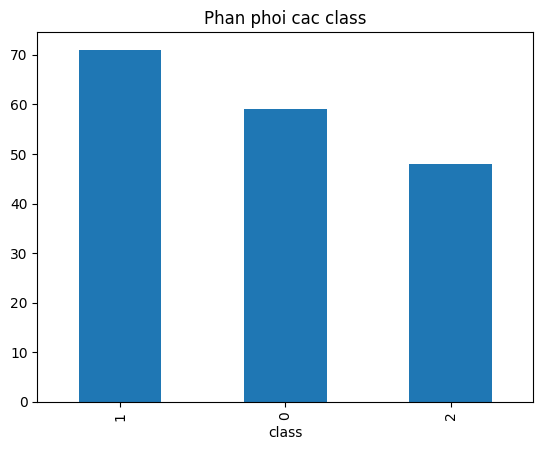

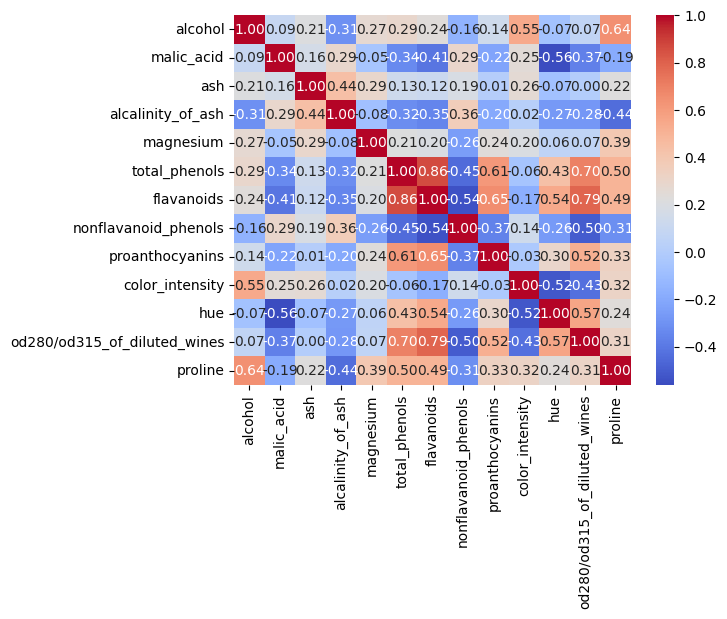

In [2]:
wine = load_wine() 
X = pd.DataFrame(wine.data, columns=wine.feature_names) 
y = pd.Series(wine.target, name='class') 
print(f'Kich thuoc: {X.shape}') 
print(f'Phan phoi class:\n{y.value_counts()}') 
print(f'Missing values: {X.isnull().sum().sum()}') 

# Visualize phan phoi class 
y.value_counts().plot(kind='bar') 
plt.title('Phan phoi cac class'); plt.show()
 
# Heatmap tuong quan 
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm') 
plt.show()

**Step 3 – Divide the file (BEFORE preprocessing)**

In [3]:
X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size=0.2, random_state=42, stratify=y 
)
print(f'Train: {X_train.shape[0]} mau | Test: {X_test.shape[0]} mau')

Train: 142 mau | Test: 36 mau


**Step 4 – Preprocessing (Scaling)**

In [4]:
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform tren train 
X_test_scaled  = scaler.transform(X_test)        # chi transform tren test! 
# KHONG fit tren test → tranh data leakage

**Step 5 – Initial Model Training**

In [5]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_initial = knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred_initial, 
                            target_names=wine.target_names))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



**Step 6 – Cross-Validation**

In [6]:
cv_scores = cross_val_score( 
    KNeighborsClassifier(n_neighbors=5), 
    X_train_scaled, y_train, 
    cv=5, scoring='f1_weighted' 
) 
print(f'F1 trung binh: {cv_scores.mean():.3f}') 
print(f'Do lech chuan: {cv_scores.std():.3f}') 
# std > 0.05 → canh bao mo hinh khong on dinh

F1 trung binh: 0.950
Do lech chuan: 0.036


**Step 7 – Grid Search (Fine Hyperparameter Adjustments)**

In [7]:
param_grid = { 
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21], 
    'weights': ['uniform', 'distance'], 
    'metric': ['euclidean', 'manhattan'] 
} 

grid_search = GridSearchCV( 
    KNeighborsClassifier(), param_grid, 
    cv=5, scoring='f1_weighted', n_jobs=-1 
) 

grid_search.fit(X_train_scaled, y_train) 
print(f'Hyperparameter tot nhat: {grid_search.best_params_}') 
print(f'F1 tot nhat (CV):        {grid_search.best_score_:.3f}') 
best_knn = grid_search.best_estimator_ 

Hyperparameter tot nhat: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
F1 tot nhat (CV):        0.986


**Step 8 – Final Evaluation on the Test Set**

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



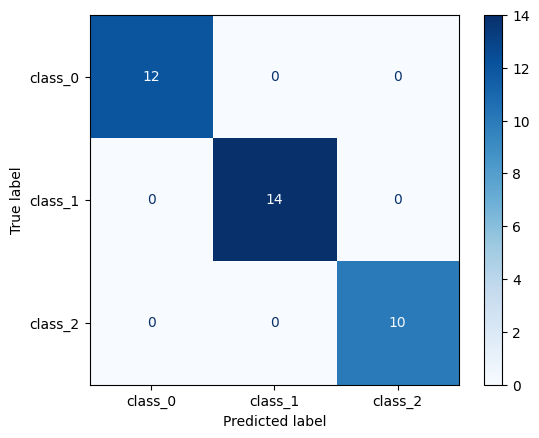

In [8]:
# Chi dung test set MOT LAN DUY NHAT 
y_pred_best = best_knn.predict(X_test_scaled) 
print(classification_report(y_test, y_pred_best, 
      target_names=wine.target_names)) 

# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred_best) 
disp = ConfusionMatrixDisplay(cm, display_labels=wine.target_names) 
disp.plot(cmap='Blues'); plt.show()

**Step 9 – Compare before/after adjustments**

In [9]:
for avg in ['macro', 'weighted']: 
    f1_before = f1_score(y_test, y_pred_initial, average=avg) 
    f1_after  = f1_score(y_test, y_pred_best, average=avg) 
    print(f'F1 ({avg}): {f1_before:.3f} → {f1_after:.3f}')

F1 (macro): 0.972 → 1.000
F1 (weighted): 0.972 → 1.000


**Step 10 – Check for Overfitting/Underfitting**

In [14]:
y_pred_train = best_knn.predict(X_train_scaled) 
f1_train = f1_score(y_train, y_pred_train, average='weighted') 
f1_test  = f1_score(y_test, y_pred_best,  average='weighted') 
gap = f1_train - f1_test 

if f1_train < 0.7: 
    print('Underfitting: model qua don gian') 
elif gap > 0.1: 
    print('Overfitting: model qua phuc tap') 
else: 
    print('Good Fit: mo hinh can bang ✓')
    
print ("F1-train: ", f1_train,)
print ("F1-test: ", f1_test,)

Good Fit: mo hinh can bang ✓
F1-train:  0.9788053777675719
F1-test:  1.0


## PART 4 ​​– VERIFYING THE RESULTS

### Self-Assessment Checklist

#### Regarding the process

**Did I split BEFORE scaling?**

Tôi đã split dataset trước khi scale vì trong code, train_test_split() được thực hiện trước StandardScaler(). Sau đó scaler chỉ được fit trên train set và chỉ transform trên test set để tránh data leakage.

**Does the scaler only call .fit() on the training set?**

Có. Trong code, scaler chỉ được .fit() trên train set thông qua fit_transform(X_train), còn test set chỉ dùng transform(X_test) để tránh data leakage.

**Is the test set strictly for one-time use?**

Có. Tôi thực hiện train_test_split() trước, sau đó mới dùng StandardScaler() để scale dữ liệu.


**"Is cross-validation performed on the training set?**

Có. Cross-validation được thực hiện trên X_train_scaled và y_train, không dùng test set nên quy trình không bị data leakage.

#### Regarding the results

**Are the F1 scores for the training and test sets reasonable (>0.6)?**

Có, rất hợp lý. Cả F1 train (~0.98) và F1 test (1.0) đều vượt xa ngưỡng 0.6, chứng tỏ mô hình không bị underfitting và dự đoán cực kỳ chính xác.

**Is the gap between training and test performance too large (>0.1)?**

Không. Khoảng cách (gap) giữa train và test chỉ khoảng 0.02, nhỏ hơn rất nhiều so với ngưỡng 0.1. Điều này cho thấy mô hình không hề bị overfitting.

**Does the confusion matrix reveal any significant class misclassifications?**

Không. Vì F1-score test đạt 1.0 (dự đoán đúng 100%), nên trên Confusion Matrix các ô ngoài đường chéo chính đều bằng 0. Không có class nào bị nhận diện nhầm.

**Do the optimized hyperparameters provide a substantial improvement over the default settings?**

Có cải thiện, F1-score tăng từ **0.972** lên **1.0**. Dù mức tăng không quá lớn do mô hình mặc định đã hoạt động rất tốt trên bộ dữ liệu này, nhưng việc tinh chỉnh giúp đạt độ chính xác tuyệt đối.

#### Regarding the understanding

**Can I justify the choice of this metric over others?**

**Can I explain each cell in the Confusion Matrix?**

**Do I know how to address overfitting if it occurs?**